# Feature Engineering & Preprocessing

In [43]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

In [44]:
df=pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df['TotalCharges']=df['TotalCharges'].replace(' ',np.nan)
df['TotalCharges']=pd.to_numeric(df['TotalCharges'])
df['TotalCharges']=df['TotalCharges'].fillna(0)

In [45]:
df_ml=df.drop('customerID',axis=1)
df_ml['Churn']=df_ml['Churn'].map({'No':0,'Yes':1})

In [46]:
df_encoded=pd.get_dummies(df_ml,drop_first=True)

In [47]:
X=df_encoded.drop('Churn',axis=1)
y=df_encoded['Churn']

In [48]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [49]:
scaler=StandardScaler()
num_cols=['tenure','MonthlyCharges','TotalCharges']
X_train[num_cols]=scaler.fit_transform(X_train[num_cols])
X_test[num_cols]=scaler.transform(X_test[num_cols])

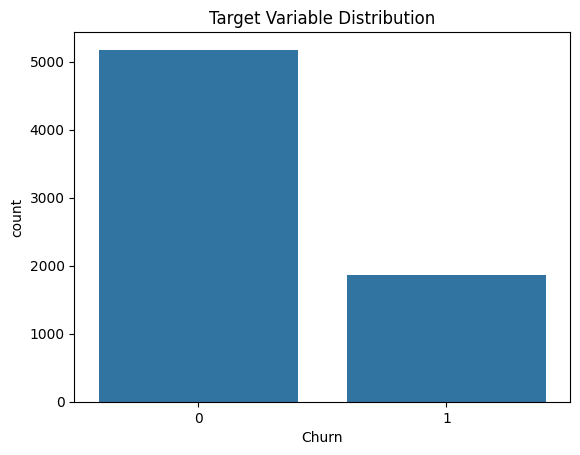

In [50]:
sns.countplot(x=y)
plt.title('Target Variable Distribution')
plt.show()

In [51]:
joblib.dump(scaler,'../models/scaler.pkl')
print('Scaler Saved Successfully')

Scaler Saved Successfully


In [52]:
joblib.dump(
    list(X_train.columns),
    "../models/feature_columns.pkl"
)

print(
    "Feature Columns Saved Successfully"
)

Feature Columns Saved Successfully


In [53]:
print('X_train Shape:',X_train.shape)
print('X_test Shape:',X_test.shape)
print('y_train Shape:',y_train.shape)
print('y_test Shape:',y_test.shape)

X_train Shape: (5634, 30)
X_test Shape: (1409, 30)
y_train Shape: (5634,)
y_test Shape: (1409,)
